In [2]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 0.18.2.


In [3]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [4]:
import os
import tarfile
from six.moves import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [5]:
fetch_housing_data()

In [6]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [7]:
housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
longitude             20640 non-null float64
latitude              20640 non-null float64
housing_median_age    20640 non-null float64
total_rooms           20640 non-null float64
total_bedrooms        20433 non-null float64
population            20640 non-null float64
households            20640 non-null float64
median_income         20640 non-null float64
median_house_value    20640 non-null float64
ocean_proximity       20640 non-null object
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
housing["ocean_proximity"].value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

In [10]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


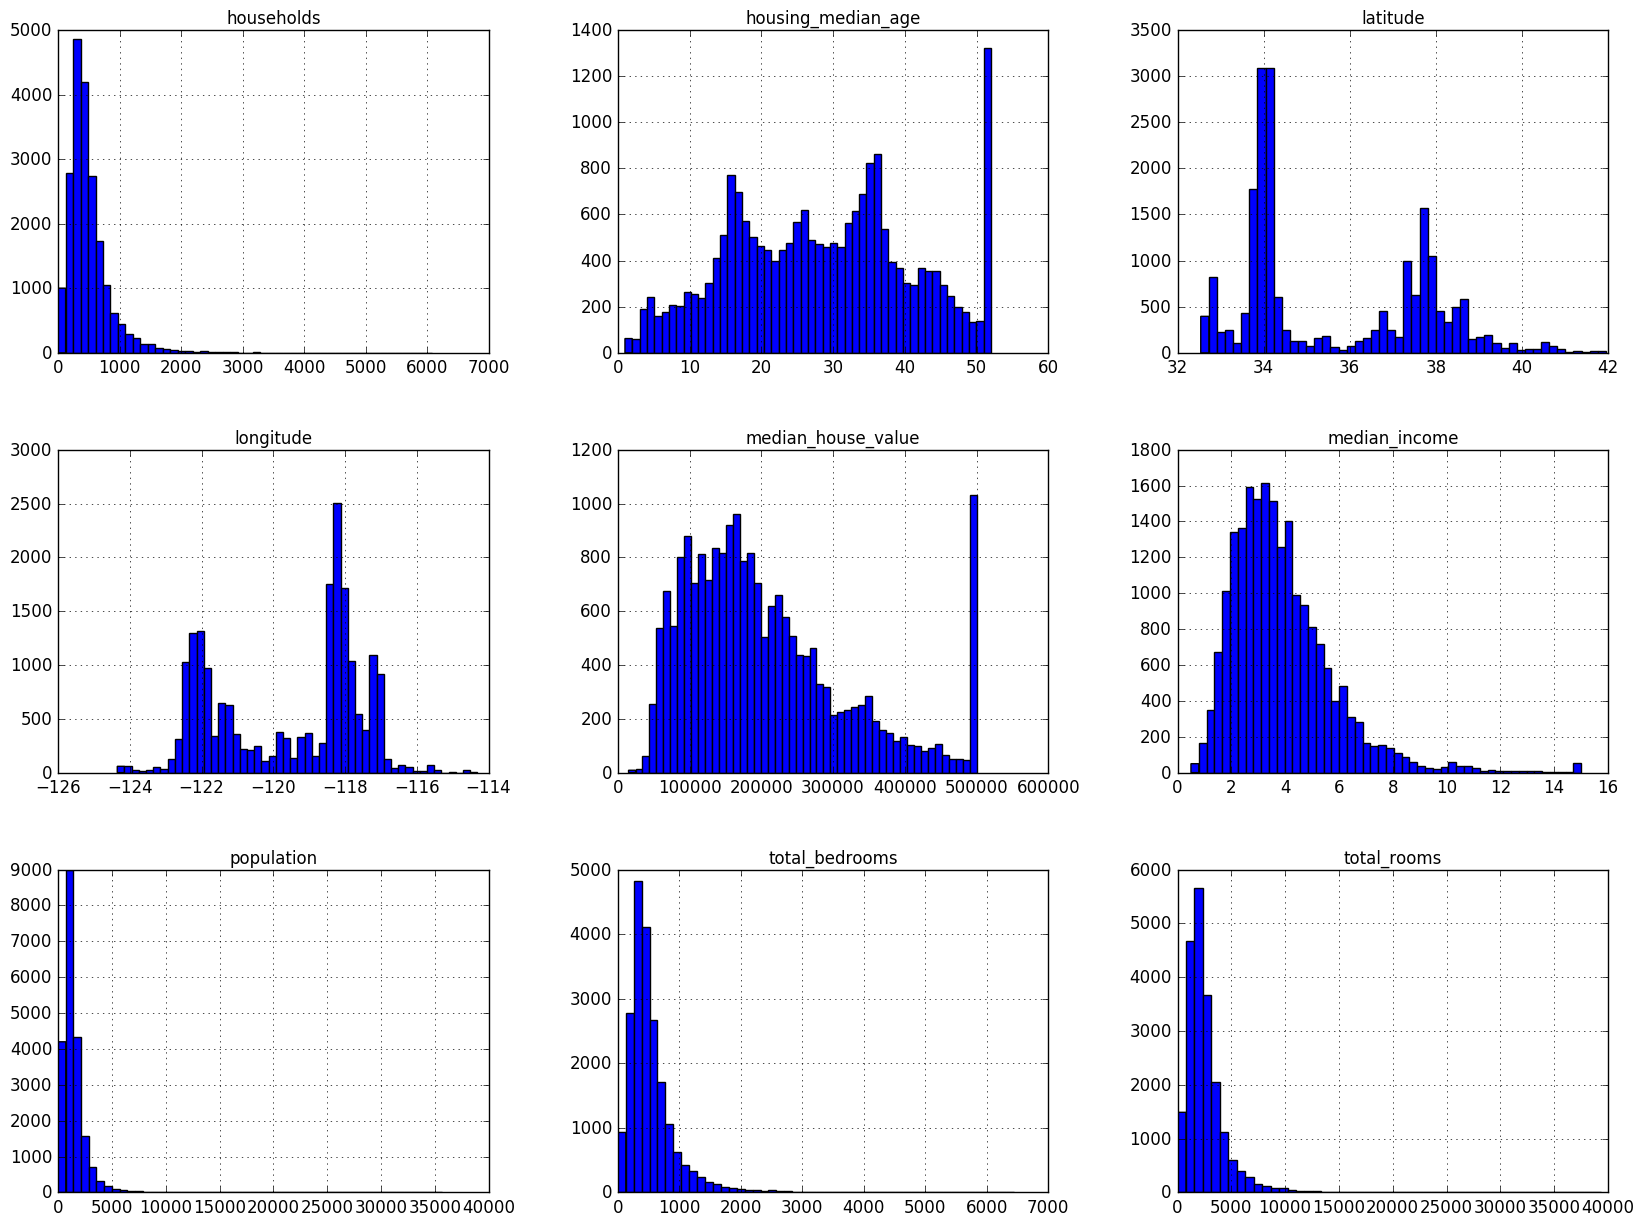

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins = 50, figsize =(20,15))
plt.show()

In [12]:
import numpy as np
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))# mix randomlly data
    test_set_size = int(len(data)*test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]
    
    

In [13]:
train_set, test_set = split_train_test(housing,0.2)

In [14]:
print(len(train_set), "train +",len(test_set), "test")

16512 train + 4128 test


In [15]:
import hashlib

def test_set_check(identifier, test_ratio, hash):
    return hash(np.int64(identifier)).digest()[-1]<256*test_ratio

def split_train_test_by_id(data, test_ratio, id_column, hash = hashlib.md5):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio, hash))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [16]:
#adds an 'index' column
housing_with_id = housing.reset_index()
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [17]:
print(len(train_set), "train +",len(test_set), "test")#you can see change in result

16362 train + 4278 test


In [18]:
from sklearn.cross_validation import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

C:\Program Files\Anaconda3\lib\site-packages\sklearn\cross_validation.py:44: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


In [19]:
print(len(train_set), "train +",len(test_set), "test")#you can see change in result

16512 train + 4128 test


In [20]:
import sklearn
from sklearn.cross_validation import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
print(len(train_set), "train +",len(test_set), "test")#you can see change in result

16512 train + 4128 test


In [21]:
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


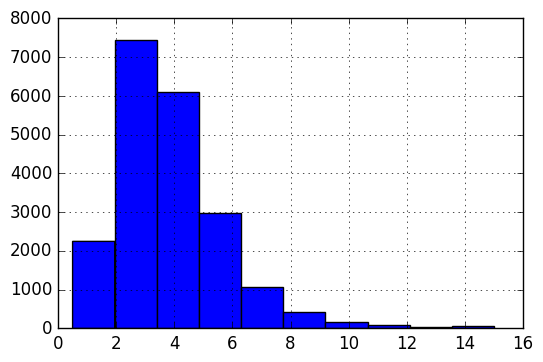

In [22]:
housing["median_income"].hist()

In [23]:
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace = True)

In [24]:
housing["income_cat"].value_counts()

3.0    7236
2.0    6581
4.0    3639
5.0    2362
1.0     822
Name: income_cat, dtype: int64

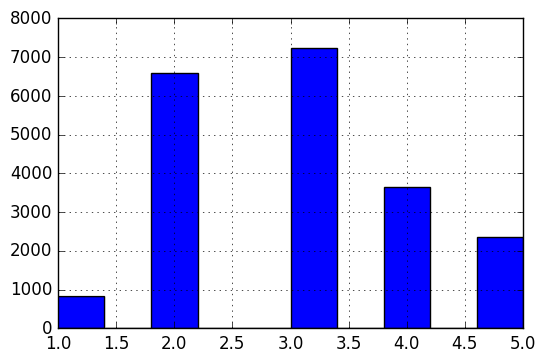

In [25]:
housing["income_cat"].hist()

In [26]:
from sklearn.model_selection import StratifiedShuffleSplit
#from sklearn.cross_validation import StratifiedShuffleSplit
split = StratifiedShuffleSplit( n_splits = 1, test_size = 0.22, random_state = 42)
for train_index, test_index in split.split(housing , housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [27]:
housing ["income_cat"].value_counts() / len(housing)


3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: income_cat, dtype: float64

In [28]:
for set in (strat_train_set, strat_test_set):
    set.drop(["income_cat"], axis = 1, inplace = True)

In [29]:
housing = strat_train_set.copy()

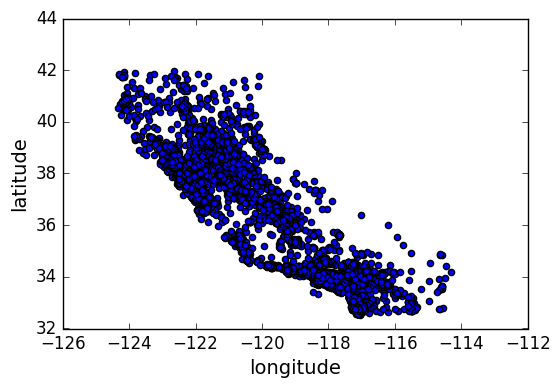

In [30]:
housing.plot(kind =  "scatter", x= "longitude", y= "latitude")
#save_fig("bad_visualization_plot")

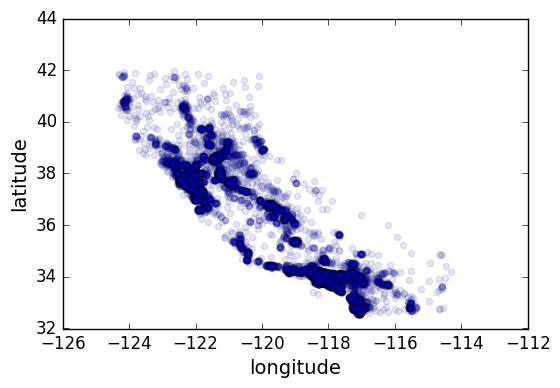

In [31]:
housing.plot(kind = "scatter", x ="longitude", y= "latitude", alpha = 0.1)

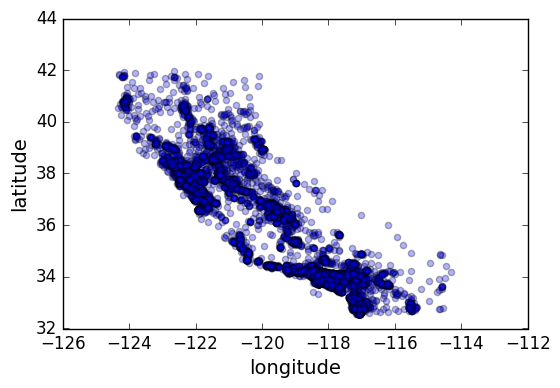

In [32]:
housing.plot(kind = "scatter", x ="longitude", y= "latitude", alpha = 0.3)

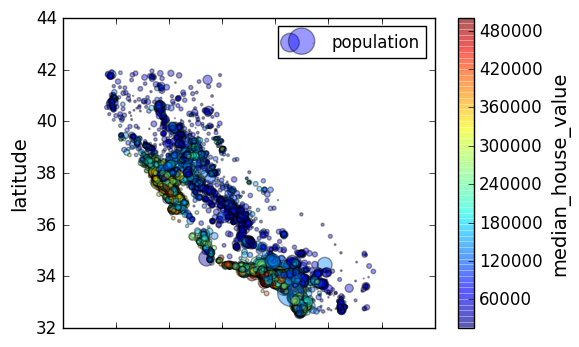

In [33]:
housing.plot(kind = "scatter", x ="longitude", y= "latitude", alpha = 0.4, s = housing["population"]/100, label = "population", c = "median_house_value", cmap = plt.get_cmap("jet"), colorbar=True)
plt.legend()

In [34]:
corr_matrix =  housing.corr()


In [35]:
corr_matrix["median_house_value"].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.686650
total_rooms           0.135428
housing_median_age    0.114898
households            0.065094
total_bedrooms        0.047958
population           -0.026435
longitude            -0.048345
latitude             -0.142424
Name: median_house_value, dtype: float64

C:\Program Files\Anaconda3\lib\site-packages\ipykernel\__main__.py:3: FutureWarning: 'pandas.tools.plotting.scatter_matrix' is deprecated, import 'pandas.plotting.scatter_matrix' instead.
  app.launch_new_instance()


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x00000236C032DDD8>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x00000236C0408320>]], dtype=object)

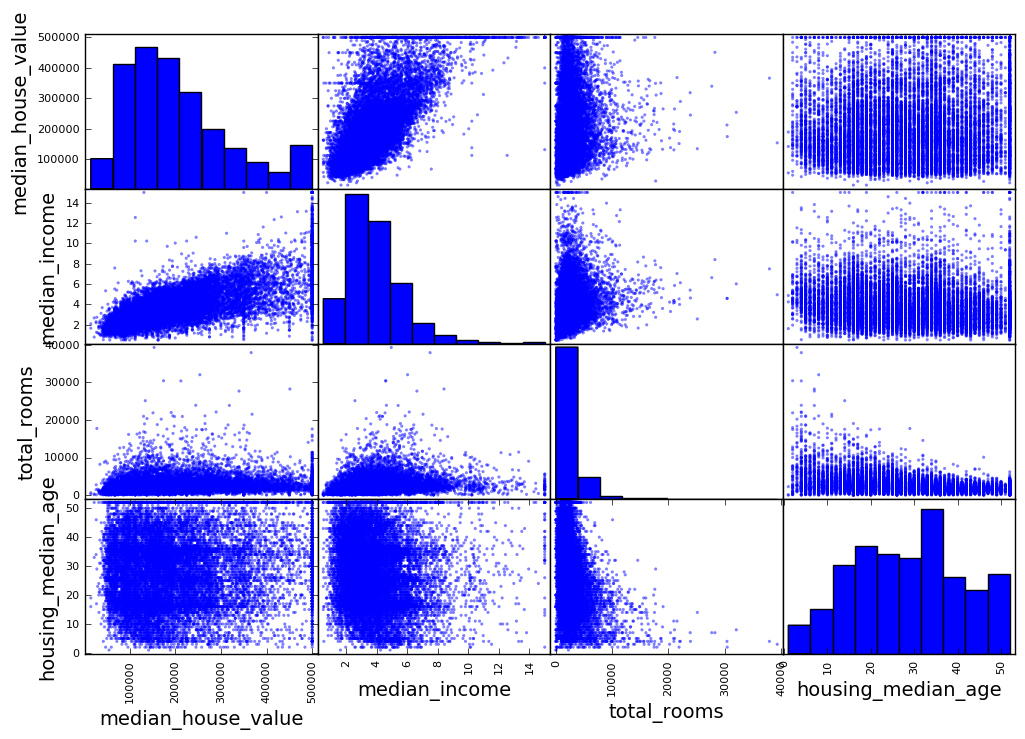

In [36]:
from pandas.tools.plotting import scatter_matrix
attributes = ["median_house_value","median_income", "total_rooms","housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12,8))

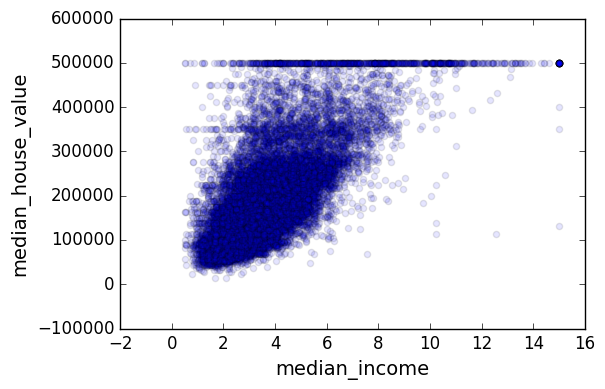

In [37]:
housing.plot(kind = "scatter", x = "median_income", y = "median_house_value", alpha = 0.1)

In [38]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"] = housing["population"]/housing["households"]

In [39]:
corr_matrix =  housing.corr()
corr_matrix["median_house_value"].sort_values(ascending = False)

median_house_value          1.000000
median_income               0.686650
rooms_per_household         0.150788
total_rooms                 0.135428
housing_median_age          0.114898
households                  0.065094
total_bedrooms              0.047958
population_per_household   -0.021908
population                 -0.026435
longitude                  -0.048345
latitude                   -0.142424
bedrooms_per_room          -0.263434
Name: median_house_value, dtype: float64

In [40]:
#prepare data for prediction
housing = strat_train_set.drop("median_house_value",axis =1)
housing_labels = strat_train_set["median_house_value"].copy()

In [41]:
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12414,-116.21,33.75,22.0,894.0,NaN,830.0,202.0,3.0673,INLAND
19402,-120.93,37.73,14.0,2799.0,NaN,2294.0,596.0,2.6343,INLAND
5654,-118.30,33.73,42.0,1731.0,NaN,866.0,403.0,2.7451,NEAR OCEAN
5236,-118.23,33.94,36.0,1110.0,NaN,1417.0,302.0,2.3333,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN


In [42]:
#test cac phuong phap hieu chinh missing label data
#we can notice that total bedrooms miss some number
#and our task is deal with the missing number

In [45]:
#option 1 get rid of the corresponding districs
sample_incomplete_rows.dropna(subset = ["total_bedrooms"])
#sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [47]:
#option 2 get rid of whole attribute
sample_incomplete_rows.drop("total_bedrooms",axis = 1)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
12414,-116.21,33.75,22.0,894.0,830.0,202.0,3.0673,INLAND
19402,-120.93,37.73,14.0,2799.0,2294.0,596.0,2.6343,INLAND
5654,-118.30,33.73,42.0,1731.0,866.0,403.0,2.7451,NEAR OCEAN
5236,-118.23,33.94,36.0,1110.0,1417.0,302.0,2.3333,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,954.0,397.0,3.7813,<1H OCEAN


In [51]:
#option 3, set the missing value is equal to median
median = housing["total_bedrooms"].median()
sample_incomplete_rows["total_bedrooms"].fillna(median, inplace = True)
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12414,-116.21,33.75,22.0,894.0,432.0,830.0,202.0,3.0673,INLAND
19402,-120.93,37.73,14.0,2799.0,432.0,2294.0,596.0,2.6343,INLAND
5654,-118.30,33.73,42.0,1731.0,432.0,866.0,403.0,2.7451,NEAR OCEAN
5236,-118.23,33.94,36.0,1110.0,432.0,1417.0,302.0,2.3333,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,432.0,954.0,397.0,3.7813,<1H OCEAN


In [54]:
from sklearn.preprocessing import Imputer
imputer =  Imputer(strategy = "median")
#drop text attibute ocean_proximity
housing_num = housing.drop("ocean_proximity", axis = 1)
imputer.fit(housing_num)

Imputer(axis=0, copy=True, missing_values='NaN', strategy='median', verbose=0)

In [57]:
imputer.statistics_

array([ -118.51  ,    34.26  ,    29.    ,  2116.    ,   432.    ,
        1163.    ,   408.    ,     3.5402])

In [58]:
housing_num.median().values

array([ -118.51  ,    34.26  ,    29.    ,  2116.    ,   432.    ,
        1163.    ,   408.    ,     3.5402])